# HH399 EDA: continuum-subtracted line maps and line-ratio diagnostics

Notebook version of `eda_line_ratios.py` / `eda_cell.py` -- same functions, run cell by cell with my own explanation before each one. Produces per-line flux maps, three diagnostic ratio maps, a tidy per-spaxel CSV, and a short physical interpretation.

=============================================================================
EDA / line-ratio cells for HH399 (MUSE cube).


WHY THE CHOICES BELOW :
 - Cube header has CTYPE3='AWAV': MUSE's wavelength solution is AIR, not
   vacuum, despite SPECSYS='BARYCENT'. Line list is entered as rest VACUUM
   wavelengths and converted to air (IAU/Morton 2000 formula) before use.
 - Halpha sits between [NII]6548/6583; the [SII] doublet lines are only
   ~15 A apart -- continuum windows are placed by hand per line to dodge
   neighbours rather than symmetric generic windows.
 - Peak-snapping (parabolic sub-pixel) on a bright-spaxel reference
   spectrum corrects small residual wavelength/velocity offsets.
 - Variance (STAT extension) is propagated through the trapezoidal line
   integral; continuum density is a robust median whose variance is
   approximated via the pi/2 median/mean Gaussian efficiency factor.
=============================================================================

## Imports

Standard stack (numpy/pandas/matplotlib) plus two *optional* astronomy libraries wrapped in `try/except`: `astropy.io.fits` (fallback FITS reader) and `mpdaf.obj.Cube` (the MUSE-specific cube object used elsewhere in the pipeline).

In [1]:
import os
os.chdir(r"e:\Desktop\Data Science\Summer Thesis astronomy project")

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, LogNorm

try:
    from astropy.io import fits
except ImportError:
    fits = None
try:
    from mpdaf.obj import Cube as MpdafCube
except ImportError:
    MpdafCube = None

## Config: line list and thresholds

The five diagnostic lines (Hα, [NII] 6583, the [SII] 6716/6731 doublet, [OIII] 5007) are entered as **rest vacuum** wavelengths -- that choice matters because the cube's wavelength axis (`CTYPE3 = 'AWAV'` in the header) is calibrated in **air**, not vacuum, so every rest wavelength has to go through the vacuum→air conversion below before it can be compared to the cube. `cont_windows` are placed by hand per line rather than as a fixed offset either side of the line, because Hα sits between the [NII] 6548/6583 pair and the two [SII] lines are only ~15 Å apart -- a symmetric window would risk eating a neighbouring line's flux into the 'continuum' estimate. `SNR_THRESHOLD = 3.0` is the standard 3σ detection cut used throughout.

In [3]:
FITS_PATH = "dataset/HH399_MUSE_WFM (1).fits"
OUTPUT_DIR = Path.cwd()
CSV_NAME = "eda_spaxels.csv"
FIGURES_DIRNAME = "figures"
VELOCITY_KMS = 0.0
SNAP_TOLERANCE_ANG = 4.0
SNR_THRESHOLD = 3.0
BRIGHT_FRACTION_FOR_SNAP = 0.2
C_KMS = 299792.458

LINES = {
    "Halpha":    dict(rest_vac=6564.61, half_width=4.0, cont_windows=[(6520, 6542), (6600, 6615)]),
    "NII_6583":  dict(rest_vac=6585.27, half_width=3.5, cont_windows=[(6600, 6615)]),
    "SII_6716":  dict(rest_vac=6718.29, half_width=2.5, cont_windows=[(6695, 6708), (6721, 6727)]),
    "SII_6731":  dict(rest_vac=6732.68, half_width=2.5, cont_windows=[(6721, 6727), (6745, 6758)]),
    "OIII_5007": dict(rest_vac=5008.24, half_width=4.0, cont_windows=[(4980, 4990), (5020, 5030)]),
}

## Loading the cube: header → wavelength axis, generic loader

`wave_from_header` rebuilds the wavelength array from the FITS WCS keywords (`CRVAL3`, `CRPIX3`, `CD3_3`/`CDELT3`) using the standard linear-axis formula `wave = CRVAL3 + (pixel - (CRPIX3-1)) * CD3_3`. `load_cube_generic` accepts three input forms (an already-open mpdaf `Cube`, a FITS path, or a bare ndarray + header) so the same EDA code can run whether or not an mpdaf `cube` object already exists in the notebook namespace. `mask_bad` turns non-finite and exact-zero pixels into NaN so they propagate cleanly through later `nanmedian`/`nansum` calls instead of silently biasing them.

In [4]:

def wave_from_header(hdr, nwave):
    crval3 = hdr.get("CRVAL3"); crpix3 = hdr.get("CRPIX3", 1.0)
    cd3 = hdr.get("CD3_3", hdr.get("CDELT3"))
    if crval3 is None or cd3 is None:
        raise KeyError("Header missing CRVAL3/CD3_3(or CDELT3) -- cannot rebuild wavelength axis.")
    idx = np.arange(nwave, dtype=np.float64)
    return crval3 + (idx - (crpix3 - 1.0)) * cd3

def mask_bad(arr, also_nonpositive=False):
    a = np.asarray(arr, dtype=np.float32).copy()
    bad = ~np.isfinite(a) | (a == 0)
    if also_nonpositive:
        bad |= (a < 0)
    a[bad] = np.nan
    return a

def load_cube_generic(source, header=None, var_array=None):
    """source: FITS path, an mpdaf Cube, or a bare (nwave,ny,nx) ndarray
    (then `header` with CRVAL3/CD3_3 or CDELT3+CRPIX3 is required)."""
    is_mpdaf = (MpdafCube is not None) and isinstance(source, MpdafCube)
    is_path = isinstance(source, (str, Path))
    is_array = isinstance(source, np.ndarray)

    if is_mpdaf:
        c = source
        data = c.data
        flux_raw = data.filled(np.nan) if np.ma.isMaskedArray(data) else np.asarray(data)
        var_raw = None
        if c.var is not None:
            v = c.var
            var_raw = v.filled(np.nan) if np.ma.isMaskedArray(v) else np.asarray(v)
        wave = np.asarray(c.wave.coord(), dtype=np.float64)
        hdr = getattr(c, "data_header", None)
    elif is_path:
        if MpdafCube is not None:
            return load_cube_generic(MpdafCube(str(source)))
        if fits is None:
            raise ImportError("Neither mpdaf nor astropy available to read the FITS cube.")
        with fits.open(source) as hdul:
            flux_raw = np.asarray(hdul["DATA"].data, dtype=np.float32)
            hdr = hdul["DATA"].header
            var_raw = np.asarray(hdul["STAT"].data, dtype=np.float32) if "STAT" in hdul else None
            wave = wave_from_header(hdr, flux_raw.shape[0])
    elif is_array:
        flux_raw = source
        var_raw = var_array
        if header is None:
            raise ValueError("Bare ndarray passed -- supply `header` (CRVAL3/CD3_3 or CDELT3+CRPIX3).")
        hdr = header
        wave = wave_from_header(hdr, flux_raw.shape[0])
    else:
        raise TypeError(f"Unsupported cube source type: {type(source)!r}")

    flux = mask_bad(flux_raw)
    var = None if var_raw is None else mask_bad(var_raw, also_nonpositive=True)
    return flux, var, wave, hdr

## Wavelength helpers: vacuum→air, Doppler shift, peak-snapping

`vacuum_to_air` implements the IAU/Morton (2000) refractive-index formula -- needed because, as noted above, the cube's dispersion solution is air-calibrated despite the header's `SPECSYS = 'BARYCENT'` implying vacuum/barycentric convention. `predicted_center` folds in an optional systemic velocity via the non-relativistic Doppler formula (`VELOCITY_KMS = 0.0` here, since HH399's local velocity offset is small compared to the line widths being integrated). `bright_reference_spectrum` builds a high-S/N reference spectrum from the brightest 20% of spaxels (by white-light flux), and `snap_peak`/`parabolic_peak` use it to correct each line's predicted center by a fraction of a pixel via parabolic interpolation of the three points around the peak -- this catches small residual wavelength-calibration offsets that a purely theoretical `rest_vac` → air conversion wouldn't capture.

In [5]:

def vacuum_to_air(wave_vac_ang):
    s = 1.0e4 / np.asarray(wave_vac_ang, dtype=np.float64)
    n = (1.0 + 0.0000834254 + 0.02406147 / (130.0 - s ** 2) + 0.00015998 / (38.9 - s ** 2))
    return wave_vac_ang / n

def predicted_center(rest_vac_ang, velocity_kms):
    return vacuum_to_air(rest_vac_ang) * (1.0 + velocity_kms / C_KMS)

def bright_reference_spectrum(flux, bright_fraction=0.2):
    white = np.nansum(flux, axis=0)
    finite = np.isfinite(white)
    if not np.any(finite):
        raise ValueError("Cube has no finite spaxels.")
    thresh = np.nanpercentile(white[finite], 100 * (1 - bright_fraction))
    bright_mask = finite & (white >= thresh)
    return np.nanmedian(flux[:, bright_mask], axis=1)

def parabolic_peak(wave, y, i):
    if i <= 0 or i >= len(y) - 1:
        return wave[i]
    y0, y1, y2 = y[i - 1], y[i], y[i + 1]
    if not np.all(np.isfinite([y0, y1, y2])):
        return wave[i]
    denom = y0 - 2 * y1 + y2
    if denom == 0:
        return wave[i]
    delta = np.clip(0.5 * (y0 - y2) / denom, -1.0, 1.0)
    return wave[i] + delta * (wave[i + 1] - wave[i])

def snap_peak(wave, ref_spectrum, predicted_wl, tol_ang):
    lo, hi = predicted_wl - tol_ang, predicted_wl + tol_ang
    idx = np.where((wave >= lo) & (wave <= hi) & np.isfinite(ref_spectrum))[0]
    if idx.size == 0:
        return predicted_wl
    i_peak = idx[np.nanargmax(ref_spectrum[idx])]
    return parabolic_peak(wave, ref_spectrum, i_peak)

## Line flux and continuum: trapezoidal integration, robust continuum, S/N

`trapz_weights` gives per-sample trapezoidal-rule weights so `integrate_line` computes a proper ∫flux dλ over the line window rather than a naive `sum()` (which would implicitly assume unit spacing). `robust_continuum` estimates the continuum level as the **median** (not mean) flux density across the hand-placed continuum windows, since the median is far less sensitive to a stray cosmic ray or an unmasked bad pixel landing in the window. Its variance uses the π/2 median-vs-mean efficiency factor for Gaussian noise (`Var(median) ≈ (π/2) · Var(mean)`) since the STAT extension only gives per-pixel variance, not a median's variance directly. `measure_line` ties it together: snap the line center, integrate flux in the window, subtract the continuum's contribution over that same window width, and propagate variance from both the line integral and the continuum estimate into a final S/N map. `snr_mask` then blanks anything below `SNR_THRESHOLD` to NaN.

In [6]:

def trapz_weights(x):
    w = np.zeros_like(x, dtype=np.float64)
    if len(x) < 2:
        return w
    w[1:-1] = (x[2:] - x[:-2]) / 2.0
    w[0] = (x[1] - x[0]) / 2.0
    w[-1] = (x[-1] - x[-2]) / 2.0
    return w

def integrate_line(flux, var, wave, lo, hi):
    idx = np.where((wave >= lo) & (wave <= hi))[0]
    if idx.size < 2:
        raise ValueError(f"Line window [{lo},{hi}] has <2 samples.")
    w = trapz_weights(wave[idx])
    sub = flux[idx]
    valid = np.all(np.isfinite(sub), axis=0)
    integ = np.nansum(w[:, None, None] * sub, axis=0)
    integ[~valid] = np.nan
    var_integ = None
    if var is not None:
        vsub = var[idx]
        var_integ = np.nansum((w[:, None, None] ** 2) * vsub, axis=0)
        var_integ[~valid] = np.nan
    return integ, var_integ, wave[idx][-1] - wave[idx][0], w

def robust_continuum(flux, var, wave, windows):
    chunks_f, chunks_v = [], []
    for lo, hi in windows:
        idx = np.where((wave >= lo) & (wave <= hi))[0]
        if idx.size == 0:
            continue
        chunks_f.append(flux[idx])
        if var is not None:
            chunks_v.append(var[idx])
    if not chunks_f:
        raise ValueError(f"No cube samples inside continuum windows {windows}.")
    allf = np.concatenate(chunks_f, axis=0)
    density = np.nanmedian(allf, axis=0)
    rms = np.nanstd(allf, axis=0)
    n_eff = np.sum(np.isfinite(allf), axis=0).astype(np.float64)
    n_eff[n_eff == 0] = np.nan
    if var is not None and chunks_v:
        allv = np.concatenate(chunks_v, axis=0)
        var_density = (np.pi / 2.0) * np.nanmean(allv, axis=0) / n_eff
    else:
        var_density = (np.pi / 2.0) * (rms ** 2) / n_eff
    return density, rms, n_eff, var_density

def measure_line(flux, var, wave, ref_spectrum, rest_vac, half_width, cont_windows, velocity_kms, snap_tol):
    predicted = predicted_center(rest_vac, velocity_kms)
    observed = snap_peak(wave, ref_spectrum, predicted, snap_tol)
    delta = observed - predicted
    lo, hi = observed - half_width, observed + half_width
    integ, var_integ, win_width, w_line = integrate_line(flux, var, wave, lo, hi)
    shifted_windows = [(a + delta, b + delta) for a, b in cont_windows]
    cont_density, cont_rms, cont_n, cont_var_density = robust_continuum(flux, var, wave, shifted_windows)
    cont_contribution = cont_density * win_width
    line_flux = integ - cont_contribution
    var_cont_contribution = (win_width ** 2) * cont_var_density
    if var_integ is not None:
        noise = np.sqrt(var_integ + var_cont_contribution)
    else:
        noise = np.sqrt(np.sum(w_line ** 2) * (cont_rms ** 2) + var_cont_contribution)
    with np.errstate(invalid="ignore", divide="ignore"):
        snr = np.where((noise > 0) & np.isfinite(noise), line_flux / noise, np.nan)
    return dict(flux=line_flux, noise=noise, snr=snr, predicted_center=predicted, observed_center=observed)

def snr_mask(result, threshold):
    bad = ~(result["snr"] >= threshold)
    out = dict(result)
    out["flux"] = np.where(bad, np.nan, result["flux"])
    out["noise"] = np.where(bad, np.nan, result["noise"])
    out["snr"] = np.where(bad, np.nan, result["snr"])
    return out

## Ratio helper

`safe_ratio` only computes `num/den` where the denominator is finite, positive, and itself above the S/N threshold -- otherwise a low-S/N or near-zero denominator would blow up into spurious extreme ratio values at the edges of the detected region. Returns NaN everywhere else so downstream plots/stats naturally skip those spaxels.

In [7]:

def safe_ratio(num_flux, den_flux, den_snr, snr_threshold, extra_mask=None):
    ratio = np.full(np.broadcast(num_flux, den_flux).shape, np.nan, dtype=np.float64)
    good = np.isfinite(num_flux) & np.isfinite(den_flux) & (den_flux > 0) & (den_snr >= snr_threshold)
    if extra_mask is not None:
        good &= extra_mask
    ratio[good] = num_flux[good] / den_flux[good]
    return ratio

## Run: load the cube

Reuses an already-loaded mpdaf `cube` variable if one exists earlier in this notebook session (e.g. from a preliminary exploration cell), otherwise loads fresh from `FITS_PATH`. Prints the cube shape and wavelength range as a sanity check before running the line measurements.

In [8]:
if "cube" in dir() and (MpdafCube is not None) and isinstance(cube, MpdafCube):
    _source = cube  # reuse the notebook's already-loaded mpdaf Cube
else:
    _source = FITS_PATH

print(f"Loading cube from: {_source!r}")
flux, var, wave, hdr = load_cube_generic(_source)
print(f"Cube shape: {flux.shape}, wavelength range: [{np.nanmin(wave):.2f}, {np.nanmax(wave):.2f}] A "
      f"({'with' if var is not None else 'WITHOUT'} variance extension)")

Loading cube from: 'dataset/HH399_MUSE_WFM (1).fits'


Cube shape: (3681, 317, 318), wavelength range: [4749.99, 9349.99] A (with variance extension)


## Run: measure all five lines

Loops `measure_line` + `snr_mask` over the `LINES` dict from the config cell, printing each line's predicted vs. peak-snapped center so the wavelength-calibration correction (see the wavelength-helpers cell) is visible and auditable line by line.

In [9]:
ref_spectrum = bright_reference_spectrum(flux, BRIGHT_FRACTION_FOR_SNAP)

results = {}
for name, lcfg in LINES.items():
    raw = measure_line(flux, var, wave, ref_spectrum, lcfg["rest_vac"], lcfg["half_width"],
                        lcfg["cont_windows"], VELOCITY_KMS, SNAP_TOLERANCE_ANG)
    masked = snr_mask(raw, SNR_THRESHOLD)
    masked["predicted_center"] = raw["predicted_center"]
    masked["observed_center"] = raw["observed_center"]
    results[name] = masked
    print(f"  {name:12s}: predicted {raw['predicted_center']:.2f} A -> snapped {raw['observed_center']:.2f} A "
          f"(delta {raw['observed_center']-raw['predicted_center']:+.2f} A)")

C:\Users\ESHAN JAIN\AppData\Local\Temp\ipykernel_5364\867944578.py:38: RuntimeWarning: All-NaN slice encountered
  density = np.nanmedian(allf, axis=0)
C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ESHAN JAIN\AppData\Local\Temp\ipykernel_5364\867944578.py:44: RuntimeWarning: Mean of empty slice
  var_density = (np.pi / 2.0) * np.nanmean(allv, axis=0) / n_eff


  Halpha      : predicted 6562.80 A -> snapped 6562.84 A (delta +0.04 A)
  NII_6583    : predicted 6583.45 A -> snapped 6583.57 A (delta +0.12 A)
  SII_6716    : predicted 6716.44 A -> snapped 6716.48 A (delta +0.04 A)
  SII_6731    : predicted 6730.82 A -> snapped 6730.95 A (delta +0.13 A)
  OIII_5007   : predicted 5006.84 A -> snapped 5006.92 A (delta +0.08 A)


  Halpha      : predicted 6562.80 A -> snapped 6562.84 A (delta +0.04 A)


  NII_6583    : predicted 6583.45 A -> snapped 6583.57 A (delta +0.12 A)


  SII_6716    : predicted 6716.44 A -> snapped 6716.48 A (delta +0.04 A)


  SII_6731    : predicted 6730.82 A -> snapped 6730.95 A (delta +0.13 A)


  OIII_5007   : predicted 5006.84 A -> snapped 5006.92 A (delta +0.08 A)


## Run: build the three ratio maps

[NII]6583/Hα and ([SII]6716+6731)/Hα are classic low-ionization diagnostic ratios -- both rise in shock-excited gas relative to purely photoionized gas, which is the physical signature this EDA is looking for along the HH399 jet. The [SII] doublet ratio 6716/6731 is a separate, density-sensitive diagnostic (not an ionization one): it runs from ~1.4-1.5 in the low-density limit down to ~0.44 in the high-density limit, so a dip along the jet ridge would indicate local compression (e.g. a bow shock).

In [10]:
ha, nii, s6716, s6731 = results["Halpha"], results["NII_6583"], results["SII_6716"], results["SII_6731"]
ratio_nii_ha = safe_ratio(nii["flux"], ha["flux"], ha["snr"], SNR_THRESHOLD)
sii_sum_flux = s6716["flux"] + s6731["flux"]
sii_sum_ok = np.isfinite(s6716["flux"]) & np.isfinite(s6731["flux"])
ratio_sii_ha = safe_ratio(sii_sum_flux, ha["flux"], ha["snr"], SNR_THRESHOLD, extra_mask=sii_sum_ok)
sii_pair_ok = (s6716["snr"] >= SNR_THRESHOLD) & (s6731["snr"] >= SNR_THRESHOLD)
ratio_sii_doublet = safe_ratio(s6716["flux"], s6731["flux"], s6731["snr"], SNR_THRESHOLD, extra_mask=sii_pair_ok)
ratios = dict(NII_Ha=ratio_nii_ha, SII_Ha=ratio_sii_ha, SII6716_6731=ratio_sii_doublet)

## Assemble tidy per-spaxel table, save CSV

Every valid spaxel (any finite flux somewhere along the wavelength axis) becomes one row, with per-line flux/S/N and per-ratio columns -- a tidy long-format table (`eda_spaxels.csv`) that's easy to filter, group, or join downstream (e.g. for the Model 1 region-map overlay, or just re-plotting without rerunning the whole extraction).

In [11]:
valid_spaxel = np.any(np.isfinite(flux), axis=0)
yy, xx = np.where(valid_spaxel)
_data = {"x": xx, "y": yy}
for name, res in results.items():
    _data[f"flux_{name}"] = res["flux"][yy, xx]
    _data[f"snr_{name}"] = res["snr"][yy, xx]
for name, r in ratios.items():
    _data[f"ratio_{name}"] = r[yy, xx]
df = pd.DataFrame(_data)

csv_path = OUTPUT_DIR / CSV_NAME
df.to_csv(csv_path, index=False)
print(f"\nSaved tidy spaxel table -> {csv_path} ({len(df)} rows)")


Saved tidy spaxel table -> e:\Desktop\Data Science\Summer Thesis astronomy project\eda_spaxels.csv (96093 rows)


## EDA summary: valid/masked counts, describe(), correlation

Basic sanity-check numbers before trusting the figures: what fraction of spaxels survive the S/N≥3 cut per line and per ratio, `df.describe()` for the usual mean/std/quartile view, and a correlation matrix between the three ratios (useful for spotting whether, e.g., [NII]/Hα and [SII]/Hα move together across the field, which would support a common shock-excitation origin rather than independent noise).

In [12]:
print(f"\nSpaxels within field of view: {len(df)}")
for name in results:
    n_good = int((df[f"snr_{name}"] >= SNR_THRESHOLD).sum())
    print(f"  {name:12s}: {n_good:7d} / {len(df):7d} above S/N >= {SNR_THRESHOLD} ({100*n_good/max(len(df),1):5.1f}%)")
for name in ratios:
    n_good = int(df[f"ratio_{name}"].notna().sum())
    print(f"  ratio_{name:16s}: {n_good:7d} / {len(df):7d} ({100*n_good/max(len(df),1):5.1f}%)")

with pd.option_context("display.max_columns", None, "display.width", 140):
    print("\ndf.describe():")
    print(df.describe())
    print("\nRatio-ratio correlation matrix:")
    print(df[[f"ratio_{n}" for n in ratios]].corr())


Spaxels within field of view: 96093
  Halpha      :   81167 /   96093 above S/N >= 3.0 ( 84.5%)
  NII_6583    :   55704 /   96093 above S/N >= 3.0 ( 58.0%)
  SII_6716    :   50588 /   96093 above S/N >= 3.0 ( 52.6%)
  SII_6731    :   49477 /   96093 above S/N >= 3.0 ( 51.5%)
  OIII_5007   :   77105 /   96093 above S/N >= 3.0 ( 80.2%)
  ratio_NII_Ha          :   53492 /   96093 ( 55.7%)
  ratio_SII_Ha          :   45483 /   96093 ( 47.3%)
  ratio_SII6716_6731    :   47296 /   96093 ( 49.2%)

df.describe():
                  x             y    flux_Halpha    snr_Halpha  flux_NII_6583  snr_NII_6583  flux_SII_6716  snr_SII_6716  flux_SII_6731  \
count  96093.000000  96093.000000   81167.000000  81167.000000   55704.000000  55704.000000   50588.000000  50588.000000   49477.000000   
mean     158.624416    158.024414   38814.451700     39.351870   13525.864075     31.840242    2864.038845     21.408729    2910.319202   
std       89.323867     90.117611   38295.651911     25.571498   21227.

                  x             y    flux_Halpha    snr_Halpha  flux_NII_6583  snr_NII_6583  flux_SII_6716  snr_SII_6716  flux_SII_6731  \
count  96093.000000  96093.000000   81167.000000  81167.000000   55704.000000  55704.000000   50588.000000  50588.000000   49477.000000   
mean     158.624416    158.024414   38814.451700     39.351870   13525.864075     31.840242    2864.038845     21.408729    2910.319202   
std       89.323867     90.117611   38295.651911     25.571498   21227.114055     27.811987    4200.061374     19.370597    5209.925109   
min        0.000000      0.000000    1441.707526      3.001977     560.825570      3.000093     186.123785      3.000072     154.396809   
25%       81.000000     80.000000   15880.507917     20.132908    2806.548786     10.354319     745.059394      7.661465     635.551305   
50%      159.000000    158.000000   28288.962127     33.750540    7797.869582     25.799038    1780.892380     16.767663    1519.711976   
75%      236.000000    236.

## Figure helpers

Two small `imshow` wrappers, one per plot type. `_imshow_flux` clips negative values (`np.clip(img, 0, None)`, since a physical flux can't be negative -- any negative values are integration noise) and applies a `PowerNorm(gamma=0.5)` stretch so faint nebular emission stays visible next to bright jet knots without the bright pixels saturating the whole colour scale. `_imshow_ratio` uses a plain linear scale since ratios don't have the same multi-order-of-magnitude dynamic range as flux. Both pick display limits from the 1st/99th (or 99.5th) percentile of the finite pixels rather than the true min/max, so a single outlier pixel can't wash out the whole map.

In [13]:

def _imshow_flux(ax, img, title, cmap="inferno"):
    finite = img[np.isfinite(img)]
    if finite.size == 0:
        ax.set_title(f"{title} (no valid data)"); ax.axis("off"); return None
    vmin, vmax = np.nanpercentile(finite, [1, 99.5])
    vmax = max(vmax, vmin + 1e-6)
    disp = np.clip(img, 0, None)
    im = ax.imshow(disp, origin="lower", cmap=cmap, norm=PowerNorm(gamma=0.5, vmin=max(vmin, 0), vmax=vmax))
    ax.set_title(title); ax.set_xlabel("x [spaxel]"); ax.set_ylabel("y [spaxel]")
    return im

def _imshow_ratio(ax, img, title, cmap="viridis", vrange=None):
    finite = img[np.isfinite(img)]
    if finite.size == 0:
        ax.set_title(f"{title} (no valid data)"); ax.axis("off"); return None
    vmin, vmax = (np.nanpercentile(finite, [1, 99]) if vrange is None else vrange)
    im = ax.imshow(img, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xlabel("x [spaxel]"); ax.set_ylabel("y [spaxel]")
    return im

figures_dir = OUTPUT_DIR / FIGURES_DIRNAME
figures_dir.mkdir(parents=True, exist_ok=True)

## Figures: per-line flux maps

One continuum-subtracted, S/N-masked flux map per line, saved to `figures/map_flux_<line>.png`. This is the most direct visual check that each line was extracted from the right part of the cube -- e.g. the Hα map should show the full nebula + jet, while [OIII] 5007 (higher ionization potential) should look more concentrated near the ionizing star.

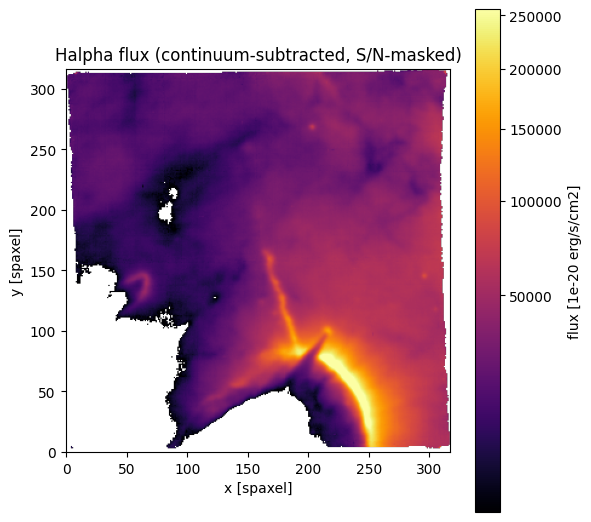

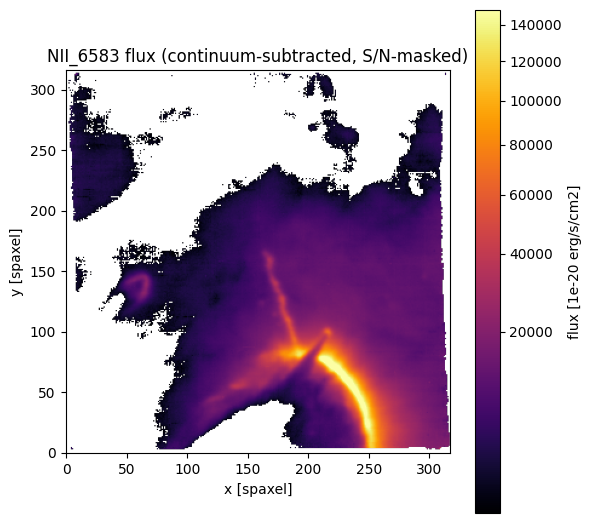

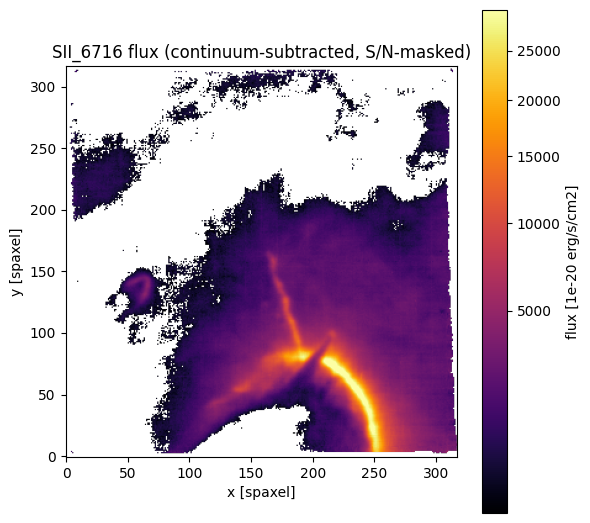

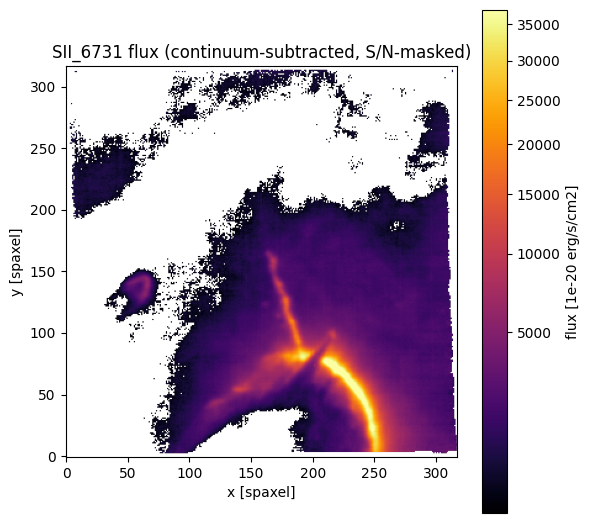

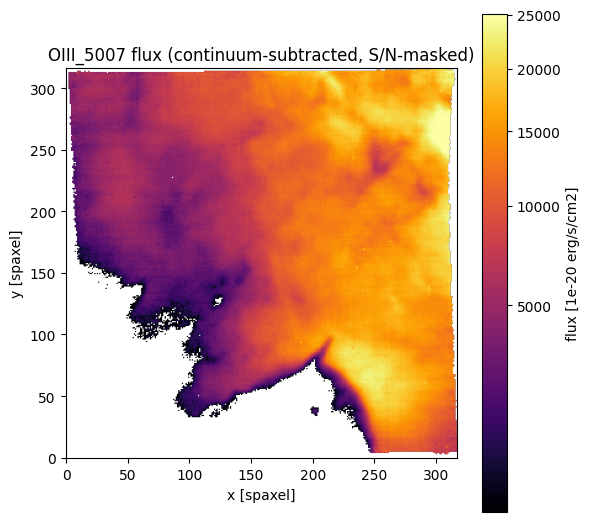

In [14]:
for name, res in results.items():
    fig, ax = plt.subplots(figsize=(6, 5.5))
    im = _imshow_flux(ax, res["flux"], f"{name} flux (continuum-subtracted, S/N-masked)")
    if im is not None:
        fig.colorbar(im, ax=ax, label="flux [1e-20 erg/s/cm2]")
    fig.tight_layout(); fig.savefig(figures_dir / f"map_flux_{name}.png", dpi=150); plt.show(); plt.close(fig)

## Figures: ratio maps

The three ratio maps side by side. [SII]6716/6731 uses a fixed colour range (0.3-1.5) instead of a percentile range like the other two, because that range is physically anchored (the density-sensitive doublet's theoretical low/high-density limits) rather than just 'whatever the data happens to span' -- makes it possible to eyeball where a spaxel sits relative to the physical density limits directly from the colour.

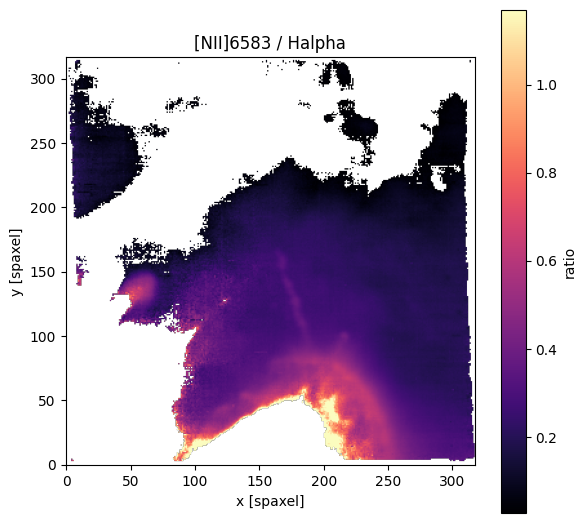

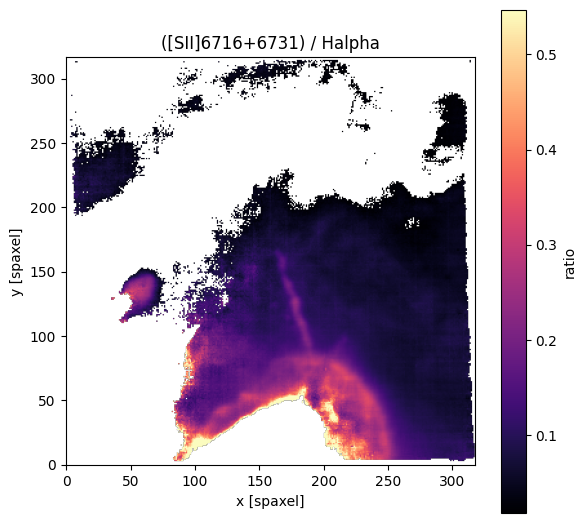

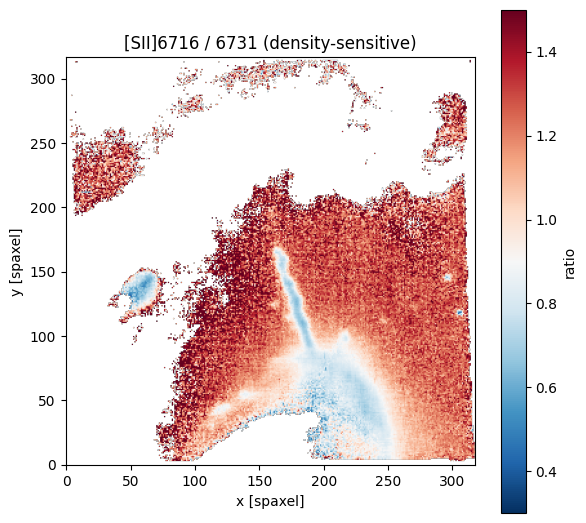

In [15]:
ratio_specs = {
    "NII_Ha": ("[NII]6583 / Halpha", "magma", None),
    "SII_Ha": ("([SII]6716+6731) / Halpha", "magma", None),
    "SII6716_6731": ("[SII]6716 / 6731 (density-sensitive)", "RdBu_r", (0.3, 1.5)),
}
for name, (title, cmap, vrange) in ratio_specs.items():
    fig, ax = plt.subplots(figsize=(6, 5.5))
    im = _imshow_ratio(ax, ratios[name], title, cmap=cmap, vrange=vrange)
    if im is not None:
        fig.colorbar(im, ax=ax, label="ratio")
    fig.tight_layout(); fig.savefig(figures_dir / f"map_ratio_{name}.png", dpi=150); plt.show(); plt.close(fig)

## Figures: ratio histograms

1D distributions of each ratio across all valid spaxels -- a check for whether the field is dominated by one population (single peak) or shows a bimodal split (e.g. diffuse photoionized gas vs. a separate shocked-jet population), which the 2D maps alone can make hard to judge quantitatively.

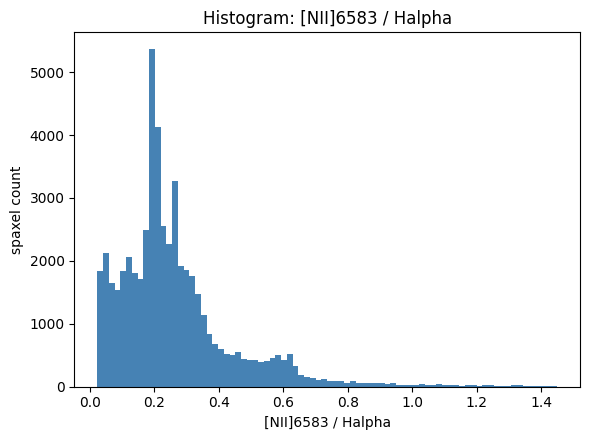

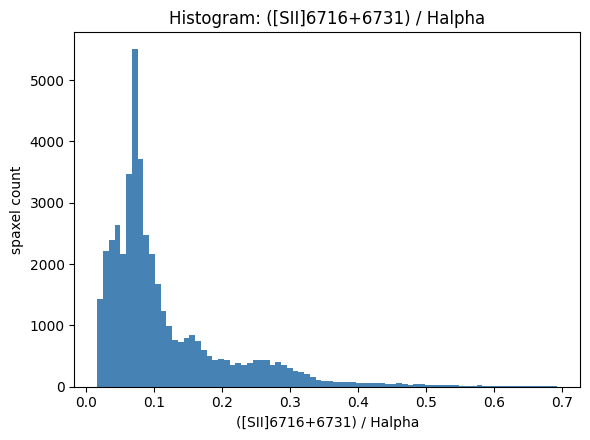

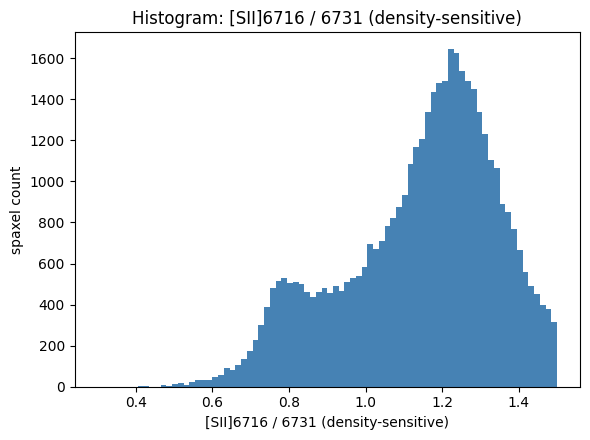

In [16]:
for name, (title, _, vrange) in ratio_specs.items():
    vals = ratios[name][np.isfinite(ratios[name])]
    fig, ax = plt.subplots(figsize=(6, 4.5))
    if vals.size > 0:
        lo, hi = (np.nanpercentile(vals, [0.5, 99.5]) if vrange is None else vrange)
        ax.hist(vals, bins=80, range=(lo, hi), color="steelblue", edgecolor="none")
    ax.set_xlabel(title); ax.set_ylabel("spaxel count"); ax.set_title(f"Histogram: {title}")
    fig.tight_layout(); fig.savefig(figures_dir / f"hist_ratio_{name}.png", dpi=150); plt.show(); plt.close(fig)

## Figures: mini ionization diagnostic (2D histogram)

A 2D log-scaled histogram of ([SII]+[SII])/Hα against [NII]/Hα per spaxel -- a scaled-down analogue of the classic BPT-style diagnostic diagrams used to separate photoionization from shock excitation. Spaxels clustering at low ratios are the diffuse photoionized nebula; a tail extending to higher ratios in both axes together is the shocked-jet population, which the log colour scale (`LogNorm`) makes visible even though it's a small minority of the total spaxel count.

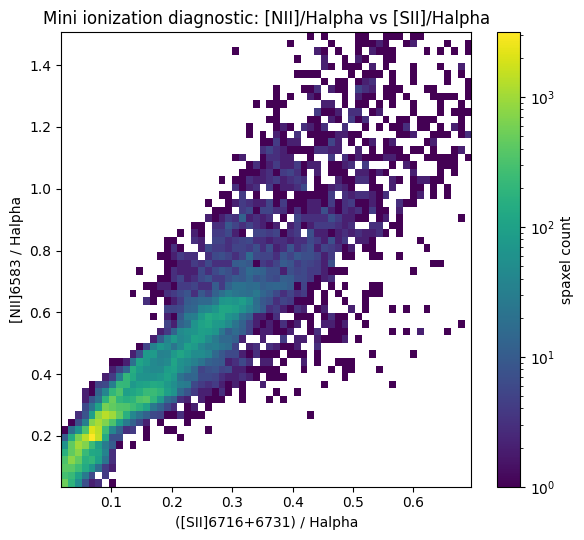


Saved figures -> e:\Desktop\Data Science\Summer Thesis astronomy project\figures


In [17]:
x, y = ratios["SII_Ha"], ratios["NII_Ha"]
good = np.isfinite(x) & np.isfinite(y)
fig, ax = plt.subplots(figsize=(6, 5.5))
if good.sum() > 0:
    xlo, xhi = np.nanpercentile(x[good], [0.5, 99.5])
    ylo, yhi = np.nanpercentile(y[good], [0.5, 99.5])
    h = ax.hist2d(x[good], y[good], bins=60, range=[[xlo, xhi], [ylo, yhi]], cmap="viridis", norm=LogNorm())
    fig.colorbar(h[3], ax=ax, label="spaxel count")
ax.set_xlabel("([SII]6716+6731) / Halpha"); ax.set_ylabel("[NII]6583 / Halpha")
ax.set_title("Mini ionization diagnostic: [NII]/Halpha vs [SII]/Halpha")
fig.tight_layout(); fig.savefig(figures_dir / "diag_NII_SII_vs_Ha.png", dpi=150); plt.show(); plt.close(fig)


## Interpretation

Pulls the median and 90th-percentile values of each ratio straight out of the arrays computed above and prints a short physical readout: whether the field-wide ratios look like photoionized diffuse/PDR gas, whether there's a coherent high-ratio ridge consistent with shock excitation along the jet, and what the doublet ratio's value implies about electron density there. Written this way (computed from the actual numbers each run produces) rather than as a static caption, so the interpretation updates automatically if the upstream extraction changes.

In [18]:

def _pct(a, p):
    v = a[np.isfinite(a)]
    return float(np.nanpercentile(v, p)) if v.size else float("nan")

nii_med, sii_med = _pct(ratios["NII_Ha"], 50), _pct(ratios["SII_Ha"], 50)
doublet_med = _pct(ratios["SII6716_6731"], 50)
nii_hi, sii_hi = _pct(ratios["NII_Ha"], 90), _pct(ratios["SII_Ha"], 90)

print("\nINTERPRETATION")
print(
    f"Across the field, [NII]6583/Halpha has a median of {nii_med:.2f} (90th pct {nii_hi:.2f}) and "
    f"([SII]6716+6731)/Halpha has a median of {sii_med:.2f} (90th pct {sii_hi:.2f}). Low-ionization "
    "ratios trace photoionized diffuse/PDR-adjacent gas; spaxels with elevated [SII]/Ha and [NII]/Ha "
    "are the shock-excitation signature expected along a Herbig-Haro jet. A spatially coherent ridge "
    "of enhanced ratios against a lower diffuse-nebula background is direct evidence of shock excitation "
    f"along the jet. The [SII]6716/6731 doublet ratio has a median of {doublet_med:.2f} (spans ~0.44 "
    "high-density limit to ~1.4-1.5 low-density limit); a value depressed toward the jet indicates locally "
    "enhanced electron density, consistent with compression in a working-surface/bow-shock segment."
)


INTERPRETATION
Across the field, [NII]6583/Halpha has a median of 0.22 (90th pct 0.53) and ([SII]6716+6731)/Halpha has a median of 0.08 (90th pct 0.26). Low-ionization ratios trace photoionized diffuse/PDR-adjacent gas; spaxels with elevated [SII]/Ha and [NII]/Ha are the shock-excitation signature expected along a Herbig-Haro jet. A spatially coherent ridge of enhanced ratios against a lower diffuse-nebula background is direct evidence of shock excitation along the jet. The [SII]6716/6731 doublet ratio has a median of 1.20 (spans ~0.44 high-density limit to ~1.4-1.5 low-density limit); a value depressed toward the jet indicates locally enhanced electron density, consistent with compression in a working-surface/bow-shock segment.


In [19]:
from mpdaf.obj import Cube

cube = Cube('dataset/HH399_MUSE_WFM (1).fits')
cube


<Cube(shape=(3681, 317, 318), unit='1e-20 erg / (Angstrom s cm2)', dtype='None')>

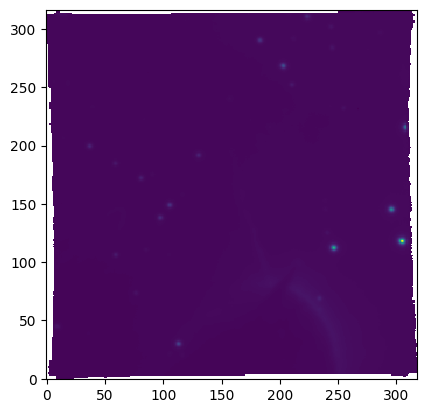

In [20]:
#White light image

white = cube.sum(axis=0)
white.plot()

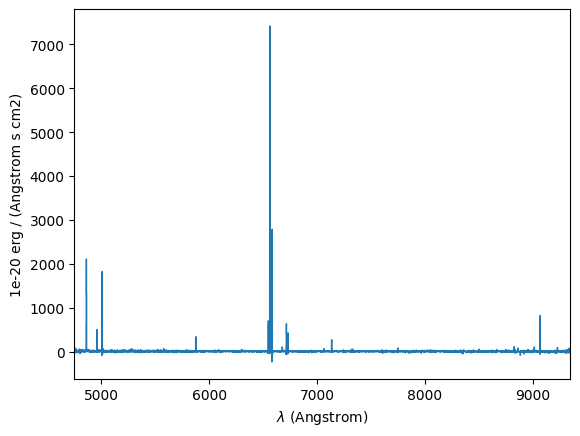

In [21]:
spec = cube[:, 150, 150]
spec.plot()

In [22]:
cube.wave.get_range()

array([4749.9921875, 9349.9921875])

In [23]:
import mpdaf
print(mpdaf.__version__)


3.6


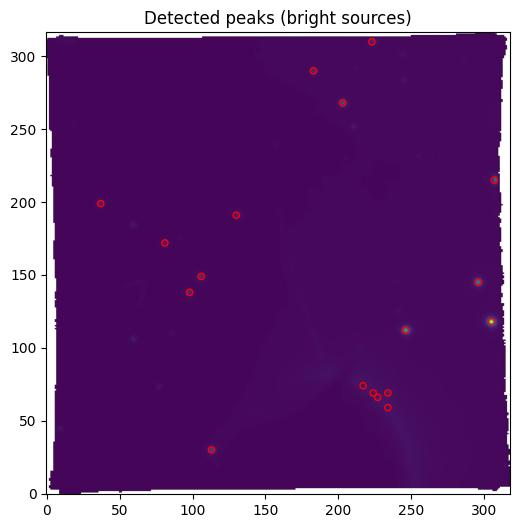

In [24]:
import numpy as np
from scipy.ndimage import maximum_filter, gaussian_filter
import matplotlib.pyplot as plt

white = cube.sum(axis=0)
data = white.data

# Smooth image to reduce noise
smooth = gaussian_filter(data, sigma=1)

# Find local maxima
neighborhood = maximum_filter(smooth, size=5)
peaks = (smooth == neighborhood) & (smooth > np.percentile(smooth, 99.5))

y, x = np.where(peaks)

plt.figure(figsize=(6,6))
plt.imshow(data, origin='lower', cmap='viridis')
plt.scatter(x, y, s=20, edgecolor='red', facecolor='none')
plt.title("Detected peaks (bright sources)")
plt.show()




In [25]:
spectra = []

for xi, yi in zip(x, y):
    spec = cube[:, yi, xi]
    spectra.append((xi, yi, spec))


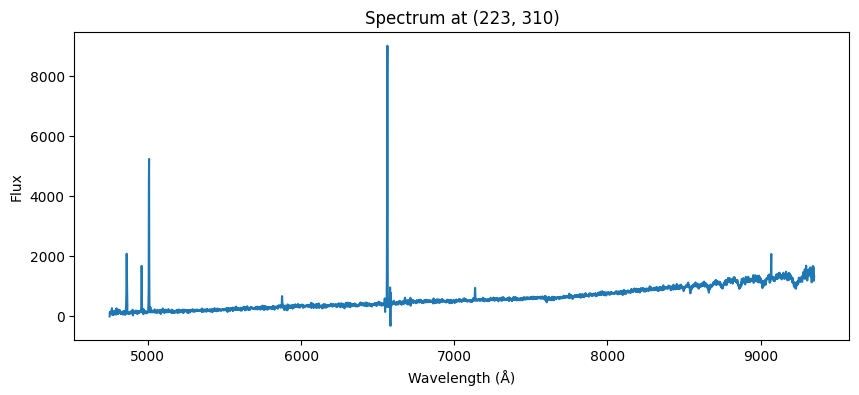

In [26]:
# Convert WaveCoord → numpy array
wave = spec.wave.coord(pixel=np.arange(spec.shape[0]))
flux = spec.data.filled(0)

plt.figure(figsize=(10,4))
plt.plot(wave, flux)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title(f"Spectrum at ({xi}, {yi})")
plt.show()




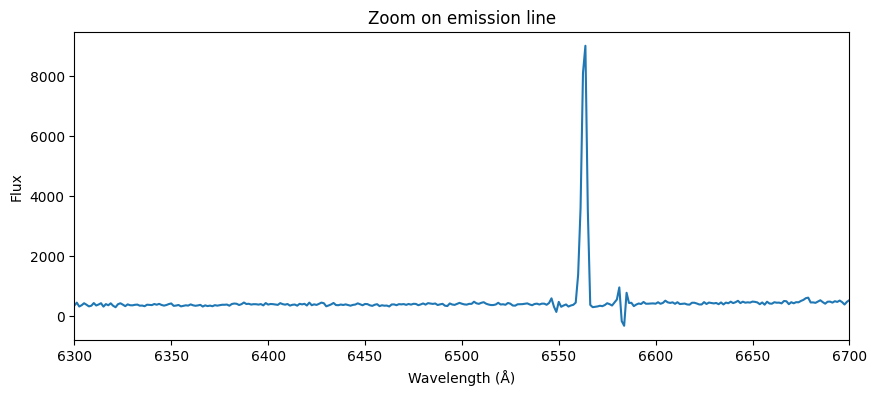

In [27]:
plt.figure(figsize=(10,4))
plt.plot(wave, flux)
plt.xlim(6300, 6700)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Zoom on emission line")
plt.show()


In [28]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(flux, height=np.percentile(flux, 99))
print(wave[peaks])


[4861.2421875 4958.7421875 5007.4921875 6563.7421875 9069.9921875
 9123.7421875 9148.7421875 9166.2421875 9278.7421875 9288.7421875
 9297.4921875 9307.4921875 9313.7421875 9318.7421875 9323.7421875
 9327.4921875 9341.2421875 9344.9921875]


In [29]:
from scipy.signal import find_peaks
import numpy as np

peaks, props = find_peaks(flux, height=np.max(flux)*0.3)  # 30% of max
print("Peak wavelengths:", wave[peaks])
print("Peak heights:", props["peak_heights"])


Peak wavelengths: [5007.4921875 6563.7421875]
Peak heights: [5226.37011719 8997.66699219]


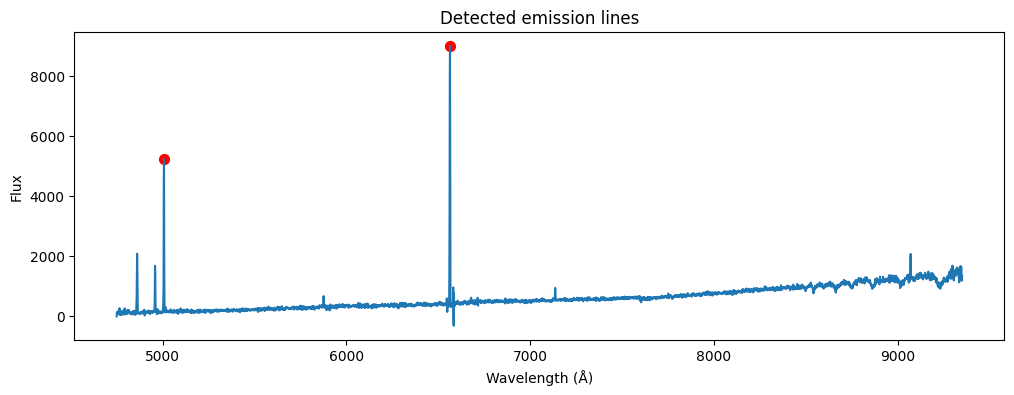

In [30]:
plt.figure(figsize=(12,4))
plt.plot(wave, flux)
plt.scatter(wave[peaks], flux[peaks], color='red', s=50)
plt.title("Detected emission lines")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.show()


In [31]:
print(flux.min(), flux.max())


-331.366943359375 8997.6669921875


In [32]:
print(flux.min(), flux.max())



-331.366943359375 8997.6669921875


In [33]:
print(spec.data.min(), spec.data.max())


-331.366943359375 8997.6669921875


In [34]:
import numpy as np

idx_main = np.argmax(flux)
lam_main = wave[idx_main]
print("Main line wavelength:", lam_main)


Main line wavelength: 6563.7421875


In [35]:
xi, yi = 115, 50   # or whichever bright pixel you used

spec = cube[:, yi, xi]
wave = spec.wave.coord(pixel=np.arange(spec.shape[0]))
flux = spec.data.filled(0)

print(flux.min(), flux.max())


-108.52461242675781 8787.279296875


In [36]:
idx_main = np.argmax(flux)
lam_main = wave[idx_main]
print("Main line wavelength:", lam_main)


Main line wavelength: 6562.4921875
